In [2]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [3]:

(X_train, y_train), (X_test, y_test) = datasets.cifar10.load_data()


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 22s 0us/step


In [4]:
X_train = X_train / 255.0
X_test = X_test / 255.0

In [5]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

In [6]:
model = models.Sequential()

model.add(data_augmentation)

model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)))
model.add(layers.MaxPooling2D(2, 2))
model.add(layers.Dropout(0.25))

model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D(2, 2))
model.add(layers.Dropout(0.25))

model.add(layers.Flatten())

model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dropout(0.5))
model.add(layers.Dense(10, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [8]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    validation_data=(X_test, y_test)
)


Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 90s 56ms/step - accuracy: 0.2624 - loss: 1.9897 - val_accuracy: 0.4719 - val_loss: 1.4927
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 86s 55ms/step - accuracy: 0.4070 - loss: 1.6329 - val_accuracy: 0.5241 - val_loss: 1.3304
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 138s 52ms/step - accuracy: 0.4395 - loss: 1.5433 - val_accuracy: 0.5247 - val_loss: 1.3192
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 84s 53ms/step - accuracy: 0.4543 - loss: 1.5138 - val_accuracy: 0.5700 - val_loss: 1.2345
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 86s 55ms/step - accuracy: 0.4725 - loss: 1.4676 - val_accuracy: 0.5595 - val_loss: 1.2718
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 84s 54ms/step - accuracy: 0.4846 - loss: 1.4403 - val_accuracy: 0.5795 - val_loss: 1.1826
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 84s 53ms/step - accuracy: 0.4863 - loss: 1.4265 - val_accuracy: 0.5747 - val_loss: 1.1701
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 142s 53ms/step - accuracy: 0.4965

In [9]:
predictions = model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step


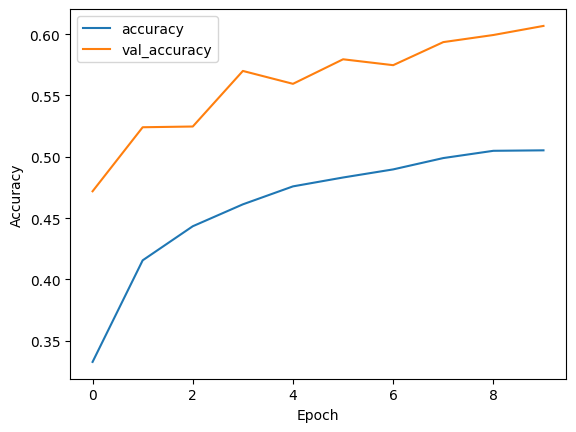

In [10]:
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()